# ⚠️ **Important Disclaimer**

Do **not edit or delete** any of the **Markdown cells** (the ones containing the questions and instructions).

Only write your answers in the **code cells provided below each question**. Try to write each answer in **one code cell** after each question.

# EPA 2021 Vehicle Fuel Economy Dataset Analysis

In this part of the assignment you will explore a comprehensive dataset of 2021 vehicle fuel economy data from the U.S. Environmental Protection Agency (EPA), covering various makes, models, and vehicle configurations.

## Dataset Overview

The dataset includes vehicle specifications, performance metrics, and fuel efficiency data such as:

- `mfr_name`, `division`, `carline` – manufacturer and model information
- `city_mpg`, `hwy_mpg`, `comb_mpg` – fuel efficiency ratings (miles per gallon)
- `engine_displacement`, `no_cylinders` – engine specifications
- `transmission_speed`, `no_gears` – transmission details
- `drive_sys`, `drive_desc` – drivetrain configuration
- `fuel_usage`, `fuel_usage_desc` – fuel type requirements
- `class`, `car_truck` – vehicle classification
- `guzzler` – gas guzzler tax indicator (Y/N)
- `air_aspir_method_desc` – engine aspiration method (naturally aspirated, turbocharged, etc.)


## Q1. Inspect Dataset

Load the packages and the dataset **`epa2021.csv`** into a pandas DataFrame.  
Perform the following tasks:

1. Display the number of **unique values** in the columns `'mfr_name'`, `'class'`, and `'fuel_usage_desc'`.  
2. Print the **number of missing values** for each column in the dataset.

In [12]:
# ANSWER HERE

# Q1. Inspect Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("epa2021.csv")

unique_counts = {
    "mfr_name": df["mfr_name"].nunique(), "class": df["class"].nunique(), "fuel_usage_desc": df["fuel_usage_desc"].nunique()
}

print("Unique Value Counts:")
for col, count in unique_counts.items():
    print(f"{col}: {count}")

df.isna().sum()


Unique Value Counts:
mfr_name: 22
class: 22
fuel_usage_desc: 6


,0
rownames,0
model_yr,0
mfr_name,0
division,0
carline,0
mfr_code,0
model_type_index,0
engine_displacement,0
no_cylinders,0
transmission_speed,0


## Q2. Handle Columns with High Missing Values

1. Calculate the **percentage of missing values** for each column in the dataset.  
2. Display only the columns that have missing values greater than 0%.  
3. Identify the columns where more than **40% of the data is missing**.  
4. Drop these high-missing-value columns from the DataFrame.
5. Print the shape of the DataFrame after these steps.

In [13]:
# ANSWER HERE

# 1. calculate missing values (%)
missing_Percentage = (df.isna().sum() / len(df)) * 100

# 2. Columns with missing values > 0%
missing_Percentage[missing_Percentage > 0]

# 3. Missing values columns with more than 40%
high_missing_cols = missing_Percentage[missing_Percentage > 40].index.tolist()
high_missing_cols

# 4. Drop high-missing-value columns
df_cleaned = df.drop(columns=high_missing_cols)

# 5. Shape before & after dropping
df.shape, df_cleaned.shape


((1108, 29), (1108, 27))

## Q3. Identify Fuel-Efficient Small Cars

Filter the dataset to select vehicles that meet all of the following criteria:  
- Combined MPG is at least **40**  
- Engine displacement is less than **2.0 liters**  
- Number of cylinders is less than or equal to **4**  

1. Print the total number of such vehicles.  
2. Show their manufacturer name, car line, engine displacement, combined MPG, and number of cylinders. All of them.

In [14]:
# ANSWER HERE
fuel_effi = df[ (df["comb_mpg"] >= 40) & (df["engine_displacement"] < 2.0) & (df["no_cylinders"] <= 4)]

fuel_effi.shape[0]

fuel_effi[["mfr_name", "carline", "engine_displacement", "comb_mpg", "no_cylinders"]]

,mfr_name,carline,engine_displacement,comb_mpg,no_cylinders
236,Honda,INSIGHT TOURING,1.5,48,4
301,Toyota,COROLLA HYBRID,1.8,52,4
369,Honda,INSIGHT,1.5,52,4
374,Hyundai,Elantra Hybrid,1.6,50,4
375,Hyundai,Elantra Hybrid Blue,1.6,54,4
453,Toyota,PRIUS,1.8,52,4
454,Toyota,PRIUS AWD,1.8,49,4
455,Toyota,PRIUS Eco,1.8,56,4
494,Hyundai,Ioniq,1.6,55,4
495,Hyundai,Ioniq Blue,1.6,59,4


## Q4. Average Engine Displacement by Drive System  

Group the dataset by the `drive_sys` column and calculate the **average engine displacement** for each drive system.  
Sort the results in descending order of average engine displacement and display the top 5 results.

In [15]:
# ANSWER HERE
avg_engine_displ_by_drive = (
    df.groupby("drive_sys")["engine_displacement"].mean().sort_values(ascending=False).head(5)
)

avg_engine_displ_by_drive

,engine_displacement
drive_sys,
4,3.776111
R,3.751812
P,3.440000
A,3.023464
F,2.125758


## Q5. Create Derived Fuel Economy Metrics  

1. Create a new column `fuel_economy_score` as a weighted average of city and highway MPG, where city MPG contributes **30%** and highway MPG contributes **70%**.  
2. Create another column `mpg_zscore` that standardizes the combined MPG (`comb_mpg`) by subtracting the mean and dividing by the standard deviation.  
3. Display the first 10 rows of the DataFrame showing the following columns:  
   - `mfr_name`, `carline`, `city_mpg`, `hwy_mpg`, `comb_mpg`, `fuel_economy_score`, and `mpg_zscore`.

In [16]:
# ANSWER HERE
df["fuel_economy_score"] = (0.3 * df["city_mpg"]) + (0.7 * df["hwy_mpg"])

df["mpg_zscore"] = (df["comb_mpg"] - df["comb_mpg"].mean()) / df["comb_mpg"].std()

df[["mfr_name", "carline", "city_mpg", "hwy_mpg", "comb_mpg","fuel_economy_score", "mpg_zscore"]].head(10)

,mfr_name,carline,city_mpg,hwy_mpg,comb_mpg,fuel_economy_score,mpg_zscore
0,Honda,NSX,21,22,21,21.7,-0.354518
1,aston martin,Vantage Manual,14,21,17,18.9,-0.975065
2,aston martin,Vantage V8,18,24,20,22.2,-0.509655
3,Volkswagen Group of,R8,13,20,16,17.9,-1.130201
4,Volkswagen Group of,R8 2WD,14,23,17,20.3,-0.975065
5,Volkswagen Group of,R8 Spyder,13,20,16,17.9,-1.130201
6,Volkswagen Group of,R8 Spyder 2WD,14,23,17,20.3,-0.975065
7,Volkswagen Group of,TT Roadster quattro,23,31,26,28.6,0.421165
8,BMW,Z4 M40i,22,30,25,27.6,0.266029
9,BMW,Z4 sDrive30i,25,32,28,29.9,0.731438


## Q6. Transmission Type Analysis  

Perform an analysis of vehicle transmissions with respect to fuel efficiency:  

1. Group the dataset by the `transmission` column.  
2. For each transmission type, calculate the following aggregations of `comb_mpg`:  
   - **mean**  
   - **standard deviation**  
   - **count** of vehicles  
3. Round all results to two decimal places.  
5. Do not forget to reset the index so that `transmission` appears as a regular column in the resulting DataFrame. Your final columns (excluding the index) should be exactly as follows:  
   - `transmission`,  `Avg_MPG`, `Std_MPG`, `Count`  
6. Sort the results by the average MPG (**Avg_MPG**) in descending order.  
7. Display the resulting table.
8. Save the final DataFrame to a CSV file named **`transmission_analysis.csv`**.

In [17]:
# ANSWER HERE
transmission_analysis = (
    df.groupby("transmission")["comb_mpg"]
      .agg(Avg_MPG="mean", Std_MPG="std", Count="count")
      .reset_index()
)

transmission_analysis = transmission_analysis.round(2)

transmission_analysis = transmission_analysis.sort_values(by="Avg_MPG", ascending=False)

transmission_analysis

transmission_analysis.to_csv("transmission_analysis.csv", index=False)


## Q7. Distribution of Fuel Economy Score  

Create a histogram to visualize the distribution of the fuel economy score that you computed above.  
Use 30 bins and overlay a kernel density estimate (KDE) curve.  
Label the axes appropriately and add a descriptive title to the plot.

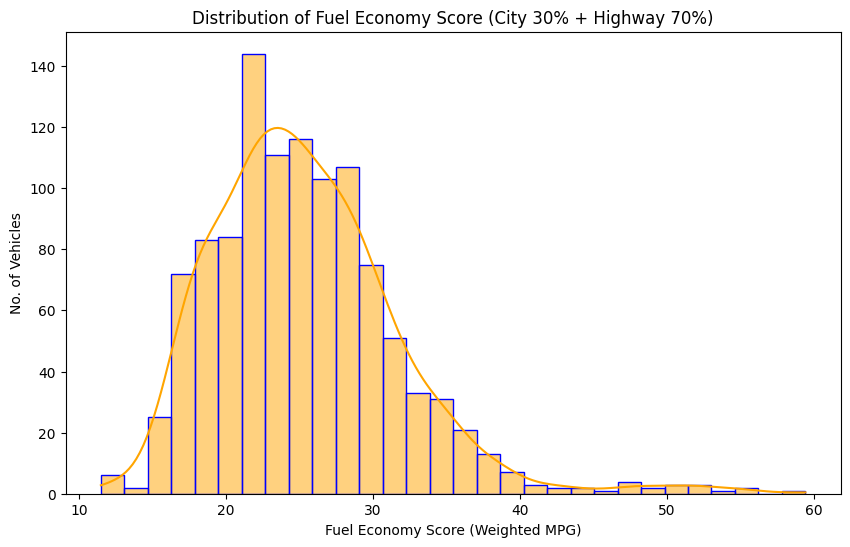

In [18]:
# ANSWER HERE
plt.figure(figsize=(10,6))
sns.histplot(df["fuel_economy_score"], bins=30, kde=True, color="Orange", edgecolor="Blue")

plt.xlabel("Fuel Economy Score (Weighted MPG)")
plt.ylabel("No. of Vehicles")
plt.title("Distribution of Fuel Economy Score (City 30% + Highway 70%)")
plt.show()


## Q8. Average MPG by Engine Displacement Range  

In this task, you will group vehicles into **engine displacement ranges**.  

1. Create a new column `displacement_bin` that categorizes vehicles into the following ranges based on their engine displacement (the category names should be simple Strings):  
   - `0-2L`  
   - `2-4L`  
   - `4-6L`  
   - `6L+`  
2. Group the dataset by this new `displacement_bin` column and calculate the **average combined MPG** for each range.  
3. Create a bar chart showing the average combined MPG per displacement range.  
   - Label the axes appropriately.  
   - Add a descriptive title.

/tmp/ipython-input-3040381339.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_mpg_by_bin = df.groupby("displacement_bin")["comb_mpg"].mean().reset_index()
/tmp/ipython-input-3040381339.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_mpg_by_bin, x="displacement_bin", y="comb_mpg", palette="Oranges")


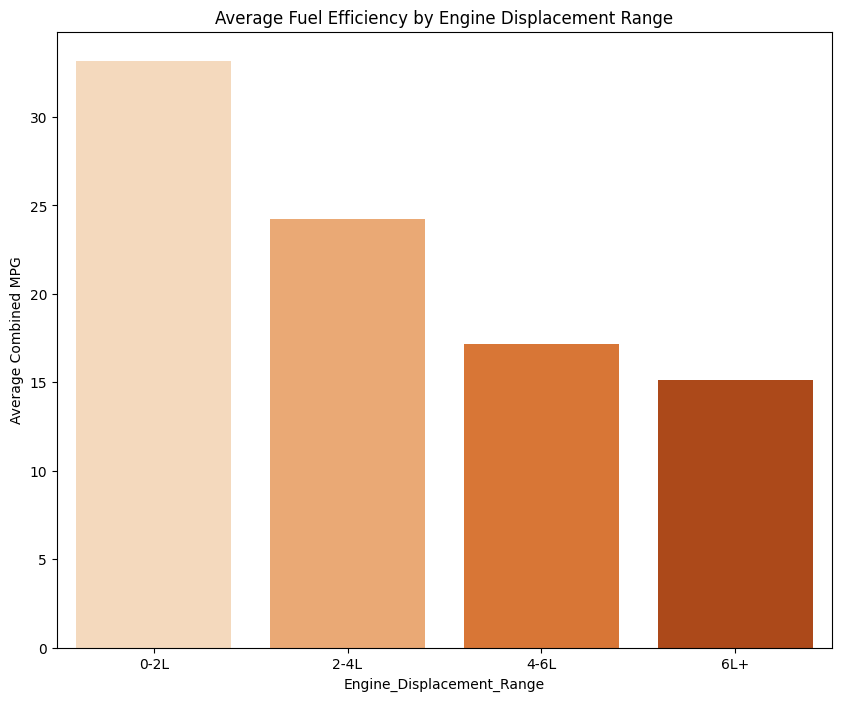

,displacement_bin,comb_mpg
0,0-2L,33.160377
1,2-4L,24.218157
2,4-6L,17.176471
3,6L+,15.133333


In [19]:
# ANSWER HERE
df["displacement_bin"] = pd.cut(
    df["engine_displacement"],
    bins=[0, 2, 4, 6, float("inf")],
    labels=["0-2L", "2-4L", "4-6L", "6L+"],
    right=False
)

avg_mpg_by_bin = df.groupby("displacement_bin")["comb_mpg"].mean().reset_index()

plt.figure(figsize=(10,8))
sns.barplot(data=avg_mpg_by_bin, x="displacement_bin", y="comb_mpg", palette="Oranges")

plt.xlabel("Engine_Displacement_Range")
plt.ylabel("Average Combined MPG")
plt.title("Average Fuel Efficiency by Engine Displacement Range")
plt.show()

avg_mpg_by_bin


## Q9. Vehicle Performance Analysis  

Create a scatter plot showing the relationship between **engine displacement** and **combined MPG**.  

- The x-axis represents **engine displacement (Liters)**.  
- The y-axis represents **combined MPG**.
- Color the points by **drive system** (`drive_sys`).  
- Scale point sizes by **number of cylinders** (`no_cylinders`).  
- Add dashed reference lines for the average engine displacement and average combined MPG. Include labels for both lines in the legend.  
- Label the axes and add a descriptive title.  

Also add:
- A legend showing the categories for drive system and cylinders.  
- Gridlines for better readability.

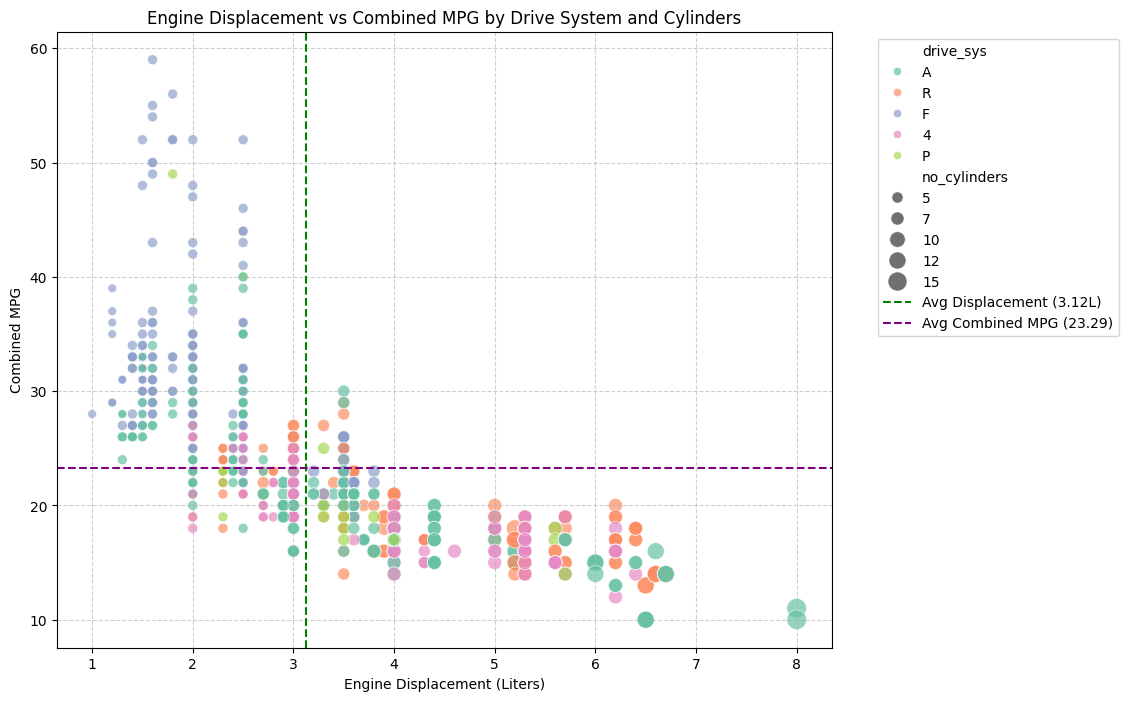

In [20]:
# ANSWER HERE
plt.figure(figsize=(10,8))

scatter = sns.scatterplot(
    data=df,
    x="engine_displacement",
    y="comb_mpg",
    hue="drive_sys",
    size="no_cylinders",
    sizes=(40, 200),
    alpha=0.7,
    palette="Set2"
)

avg_displ = df["engine_displacement"].mean()
avg_mpg = df["comb_mpg"].mean()

plt.axvline(avg_displ, color="Green", linestyle="--", label=f"Avg Displacement ({avg_displ:.2f}L)")
plt.axhline(avg_mpg, color="purple", linestyle="--", label=f"Avg Combined MPG ({avg_mpg:.2f})")

plt.xlabel("Engine Displacement (Liters)")
plt.ylabel("Combined MPG")
plt.title("Engine Displacement vs Combined MPG by Drive System and Cylinders")
plt.grid(True, linestyle="--", alpha=0.6)

handles, labels = scatter.get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()


## Q10. Recreate the Heatmap with Pivot Table

Your task is to reproduce the following figure as closely as possible.  

**Important:** You **must** use a **pivot table** to solve this problem.

Here are a few helpful hints:  
- The plot was created using **Seaborn's `heatmap()`** function.  
- The color map used is **YlGnBu**.  

Start with a basic heatmap, then refine it by adding/adjusting:  
- annotations  
- ticks  
- labels  
- borders  
- title and axis labels  

**Save your final plot as a PDF file named:**  
`city_mpg_heatmap.pdf`

### Reference Figure

![Reference Heatmap](reference_heatmap.png)

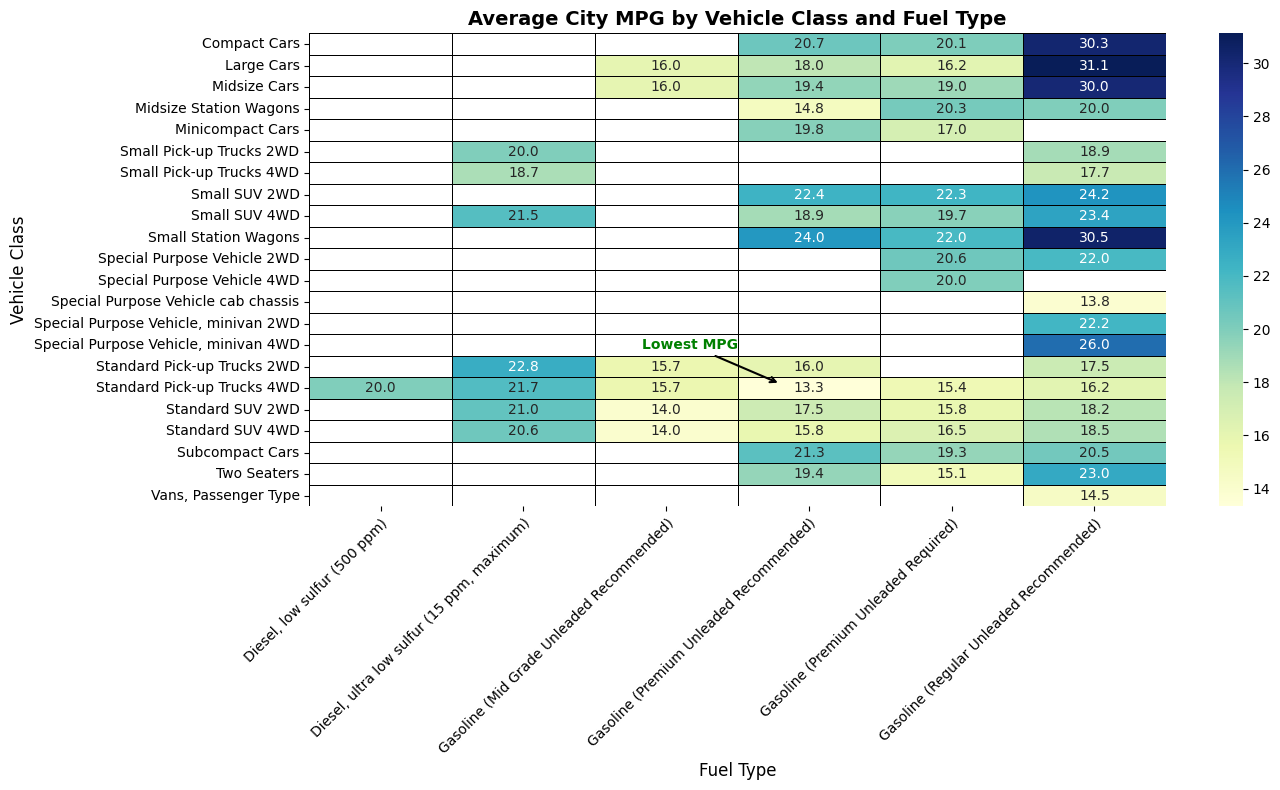

In [21]:
# Heat map with pivot table
pivot = pd.pivot_table(
    df,
    values='city_mpg',
    index='class',     # rows
    columns='fuel_usage_desc',      # columns
    aggfunc='mean',

)

plt.figure(figsize=(14,8))

ax = sns.heatmap(
    pivot,
    cmap="YlGnBu",          # color map
    annot=True,             # show values
    fmt=".1f",              # one decimal place
    linewidths=0.5,         # borders
    linecolor="black"
)

ax.set_xticks(np.arange(pivot.shape[1])+0.5);
ax.set_xticklabels(list(map(str,pivot.columns)), rotation=45, ha='right', rotation_mode='anchor'); plt.subplots_adjust(bottom=0.25)


plt.title("Average City MPG by Vehicle Class and Fuel Type", fontsize=14, weight='bold')
plt.xlabel("Fuel Type", fontsize=12)
plt.ylabel("Vehicle Class", fontsize=12)

min_value = pivot.min().min()                   # Lowest MPG value
min_row, min_col = None, None

# Iterate to find the indices of the min value
for i, row in enumerate(pivot.index):
    for j, col in enumerate(pivot.columns):
        if pivot.loc[row, col] == min_value:
            min_row, min_col = i, j



plt.annotate(
    'Lowest MPG',
    xy=(min_col + 0.3, min_row + 0.3),
    xycoords='data',
    xytext=(-65,25),
    textcoords='offset points',
    ha='center',
    color='Green',
    weight='bold',
    arrowprops=dict(
        facecolor='green',    # arrow head fill
        edgecolor='black',    # arrow outline/shaft
        arrowstyle='->',
        linewidth=1.5
    )
)

plt.tight_layout()

plt.savefig("city_mpg_heatmap.pdf")

plt.show()